# Between-scanner, within-scanner and between-paradigm variability of FC matrices

In [1]:
library(reticulate)
library(tidyr)
library(MANOVA.RM)
library(irr)
library(effectsize)
use_python("/home/cprovins/miniconda3/envs/pymc_env/bin/python", required = TRUE)

Loading required package: lpSolve



### Load the FC matrices

We load the functional connectivity (FC) matrices using Python code so we can conveniently leverage our custom configuration for PyBIDS. Which scanner was the participant scanned on during the generalization sessions is encoded in the last three digits of the session number (Prisma=060, Vida=034, VidaFit=030). For the investigation of the paradigm influence, we keep only the generalization sessions using the Prisma scanner.

In [2]:
py_run_string('
import re
import pandas as pd
from pathlib import Path
from bids.layout import BIDSLayout, BIDSLayoutIndexer, add_config_paths

# Define filtering parameters
metric = "sparseinversecovariance"
atlas_dimension = "64"
fd_threshold = 0.5
fdthresh_str = str(fd_threshold).replace(".", "")

# Define paths
code_path = Path("/data/code/hcph-sops/")
fc_path = Path(f"/data/derivatives/hcph-fc")

# Initialize the BIDS layout
config_path = code_path / "code/bids/indexer.json"
try:
    add_config_paths(hcph=config_path)
except ValueError as e:
    if "Configuration \'hcph\' already exists" in str(e):
        print("Configuration hcph already exists, skipping add_config_paths.")
    else:
        raise e

_indexer = BIDSLayoutIndexer(
    config_filename=config_path,
    index_metadata=False,
    validate=False,
)       
layout = BIDSLayout(fc_path, config="hcph", indexer=_indexer, validate=False)

# Define entities common to all files
entities_base = {
    "subject": "001",
    "measure": metric,
    "scale": atlas_dimension,
    "fd_threshold": fdthresh_str,
}

## Load FC matrices for the generalization sessions
entities_base_gen = {
    **entities_base,
    "task": "rest",
}
# Get functional connectivity files
files_gen = layout.get(**entities_base_gen, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_gen) == 36, f"Expected 36 FC matrices, got {len(files_gen)}"
df_fc = pd.DataFrame({"filename": files_gen, "subject": "001"})

# Retrieve which scanner was used for each session (encoded in the last three digits of the session ID)
df_fc["session"] = df_fc["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)

def extract_scanner(session):
    scanner_codes = {"060": "prisma", "034": "vida", "030": "vidafit"}
    code = session[-3:]
    return scanner_codes.get(code, "unknown")

df_fc["scanner"] = df_fc["session"].apply(extract_scanner)
df_fc["repetition"] = df_fc["session"].str[1:3].astype(int)

## Load FC matrices from the reliability sessions
entities_base_rel = {
    **entities_base,
    "task": "rsmovie",
}
files_rel = layout.get(**entities_base_rel, suffix="connectivity", extension=".tsv", return_type="file")
assert len(files_rel) == 36, f"Expected 36 FC matrices, got {len(files_rel)}"
df_rsmovie = pd.DataFrame({"filename": files_rel, "task": "rsmovie", "subject": "001"})
df_rsmovie["session"] = df_rsmovie["filename"].apply(lambda x: re.search(r"ses-(\\d+)", x).group(1) if re.search(r"ses-(\\d+)", x) else None)
df_rsmovie["repetition"] = df_rsmovie.index + 1

# Keep only the session with prisma scanner for investigation of paradigm influence
df_fc_paradigm = df_fc[df_fc["scanner"] == "prisma"]
df_fc_paradigm = df_fc_paradigm.drop(columns=["scanner"])
df_fc_paradigm["task"] = "rest"
assert len(df_fc_paradigm) == 12, f"Expected 12 FC matrices for prisma scanner, got {len(df_fc_paradigm)}"

## Concatenate the two dataframes
df_fc_paradigm = pd.concat([df_fc_paradigm, df_rsmovie], ignore_index=True)
assert len(df_fc_paradigm) == 48, f"Expected 48 FC matrices after concatenation, got {len(df_fc_paradigm)}"
')

In [3]:
## Helper function to load the FC matrices from the file paths
load_fc_matrices <- function(df) {
    # Load all FC matrices and add the upper triangle flattened to the dataframe.
    # Since the FC matrix is symmetric, retaining only the upper triangle is sufficient.
    for (i in seq_len(nrow(df))) {
        tsv_file <- df$filename[i]
        mat <- as.matrix(read.table(tsv_file, header = FALSE, sep = "\t"))
        if (grepl("sparseinversecovariance", tsv_file)) {
            # Negate the precision matrix to get partial correlations
            mat <- -mat
        }
        # Flatten the upper triangle of the matrix (excluding diagonal)
        flat <- mat[upper.tri(mat, diag = FALSE)]
        col_names <- paste0("edge", seq_along(flat))
        # Add values to the dataframe
        for (j in seq_along(flat)) {
            df[i, col_names[j]] <- flat[j]
        }
    }
    # Remove the filename column as it is no longer needed
    df$filename <- NULL
    return(df)
}

In [4]:
# Load the panda DataFrame into R
df_fc <- as.data.frame(py$df_fc)
df_fc <- load_fc_matrices(df_fc)
stopifnot(nrow(df_fc) == 36) #assert statement

df_rsmovie <- as.data.frame(py$df_rsmovie)
df_rsmovie <- load_fc_matrices(df_rsmovie)
stopifnot(nrow(df_rsmovie) == 36)

df_fc_paradigm <- as.data.frame(py$df_fc_paradigm)
df_fc_paradigm <- load_fc_matrices(df_fc_paradigm)
stopifnot(nrow(df_fc_paradigm) == 48)
head(df_fc)

,subject,session,scanner,repetition,edge1,edge2,edge3,edge4,edge5,edge6,⋯,edge1882,edge1883,edge1884,edge1885,edge1886,edge1887,edge1888,edge1889,edge1890,edge1891
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,001,20101060,prisma,1,5.713746e-07,6.540584e-07,7.533472e-02,7.260873e-02,-6.969980e-07,-1.520290e-06,⋯,-7.589415e-18,-2.301706e-17,-4.420834e-17,-9.459664e-17,3.980266e-02,-2.027458e-17,2.348138e-17,1.734723e-18,4.349188e-02,5.167582e-17
2,001,20102030,vidafit,1,-3.001827e-06,-8.633434e-07,7.434885e-03,6.236161e-02,-2.234694e-06,-9.196300e-07,⋯,-1.006140e-16,-1.252525e-16,-3.995963e-17,-3.835365e-18,1.313193e-01,1.972221e-17,5.607677e-17,-1.649754e-17,3.675526e-18,-1.750475e-18
3,001,20103034,vida,1,6.528042e-06,7.514955e-06,6.689939e-02,7.235371e-06,-7.886987e-07,7.797121e-06,⋯,-3.903128e-16,9.413585e-17,-2.438371e-16,0.000000e+00,1.557758e-01,-1.322727e-16,-1.104921e-16,1.066855e-16,3.918115e-02,-1.469841e-16
4,001,20201060,prisma,2,3.904534e-07,1.515389e-06,3.453112e-06,-1.415896e-05,-2.232815e-07,-2.602339e-06,⋯,-2.295798e-17,3.557305e-17,1.848350e-17,-3.483355e-17,-6.859457e-17,1.501620e-17,-1.430277e-16,-4.933120e-17,2.647703e-03,-3.850324e-17
5,001,20202030,vidafit,2,-1.454936e-06,-1.157484e-06,9.403329e-03,2.148322e-05,-1.280872e-06,1.658403e-06,⋯,4.530888e-02,-7.994925e-17,-2.787828e-17,-8.960982e-17,9.983821e-02,3.426079e-17,-1.062243e-16,1.301043e-17,1.928596e-02,4.744856e-17
6,001,20203034,vida,2,-4.514564e-06,2.766009e-02,1.460895e-05,4.672855e-04,-4.646385e-06,-2.661734e-07,⋯,4.049618e-02,-1.033938e-16,5.771188e-17,-1.590655e-16,-4.655646e-17,-1.710574e-16,-8.704852e-17,1.002208e-16,-7.124293e-17,-2.062372e-17


## Intra-class correlation coefficient (ICC) to quantify between-scanner variability

In [5]:
icc_results <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Iterate over all edges
col_names <- colnames(df_fc)
#Remove non-iqms column names
edge_keys <- col_names[c(-1,-2,-3, -4)]
if (any(!grepl("^edge", edge_keys))) {
    stop("All elements in edge_keys must contain 'edge'")
}
for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_fc[, c( "scanner", edge)]
    df_icc <- pivot_wider(df_icc, names_from = scanner, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(prisma, vida, vidafit))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_results <- rbind(icc_results, data.frame(edge = edge, ICC = icc_val))
}
head(df_icc)
head(icc_results)

Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(edge)

  # Now:
  data %>% select(all_of(edge))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”


prisma,vidafit,vida
<dbl>,<dbl>,<dbl>
5.167582e-17,-1.750475e-18,-1.469841e-16
-3.850324e-17,4.744856e-17,-2.062372e-17
1.681766e-17,5.344078e-18,1.076156e-16
-1.098919e-16,1.718209e-17,1.452872e-17
1.035807e-02,-5.010170e-17,6.270949e-17
-7.349301e-17,-1.836159e-16,-8.626545e-17


,edge,ICC
,<chr>,<dbl>
1,edge1,-0.0172390994
2,edge2,-0.0469087433
3,edge3,-0.0234311629
4,edge4,-0.1738795027
5,edge5,-0.0539968901
6,edge6,-0.0003582582


Mean ICC across edges: -0.02419042 
Median ICC across edges: -0.01757463 


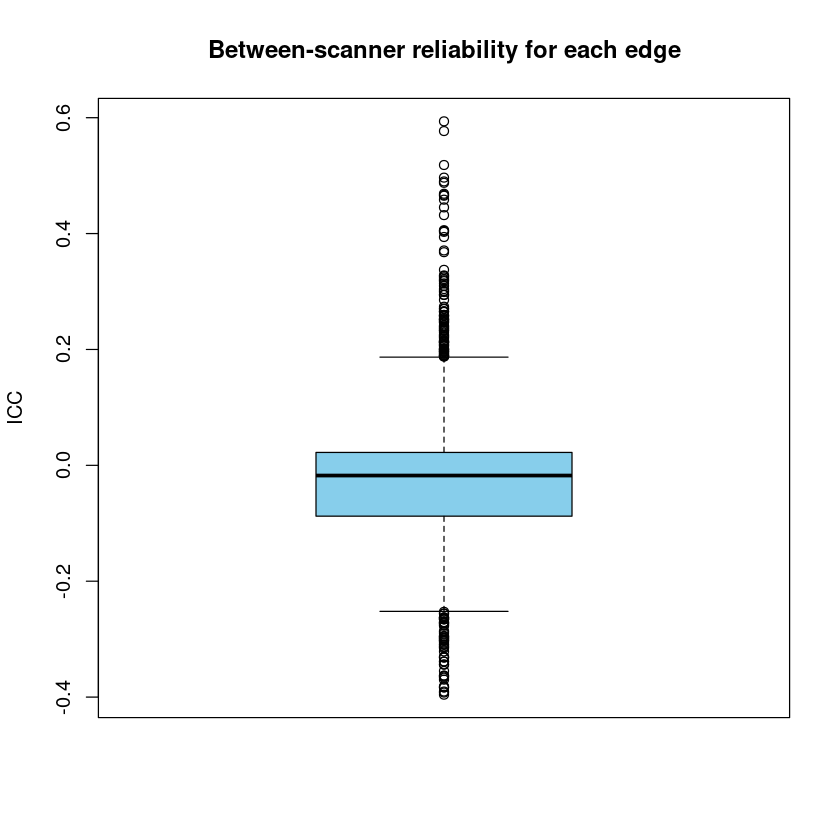

In [6]:
mean_icc <- mean(icc_results$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_results$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_results$ICC, main = "Between-scanner reliability for each edge", ylab = "ICC", col = "skyblue")

In [24]:
icc_between <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), stringsAsFactors = FALSE)

# Iterate over all possible combinations of repetition numbers for the 3 scanners
scanners <- unique(df_fc$scanner)
for (rep1 in unique(df_fc$repetition)) {
  for (rep2 in unique(df_fc$repetition)) {
    for (rep3 in unique(df_fc$repetition)) {

        # Extract that permutation of repetitions
        reps <- c(rep1, rep2, rep3)
        df_rep <- data.frame()
        for (i in 1:3) {
          df_one <- subset(df_fc, scanner == scanners[i] & repetition == reps[i])
          df_rep <- rbind(df_rep, df_one)
        }

        # Keep only the edge column and trasnpose the dataframe
        df_edges <- t(df_rep[, edge_keys])  # rows: edges, cols: scanners
        colnames(df_edges) <- scanners

        # Compute ICC(2,1)
        icc_val <- icc(df_edges, model = "twoway", type = "agreement", unit = "single")$value

        # Store the results
        icc_between <- rbind(
            icc_between,
            data.frame(
            variability_type = "between-scanner",
            task = "rest",
            scanner = NA,
            repetition = paste0(rep1, "-", rep2, "-", rep3),
            ICC = icc_val,
            summary_statistic = NA
            )
        )  
    }
  }
}
head(df_rep)
icc_between

Mean ICC across edges: 0.8150217 
Quantiles (25%, median, 75%): 0.8085429 0.8164412 0.8233663 


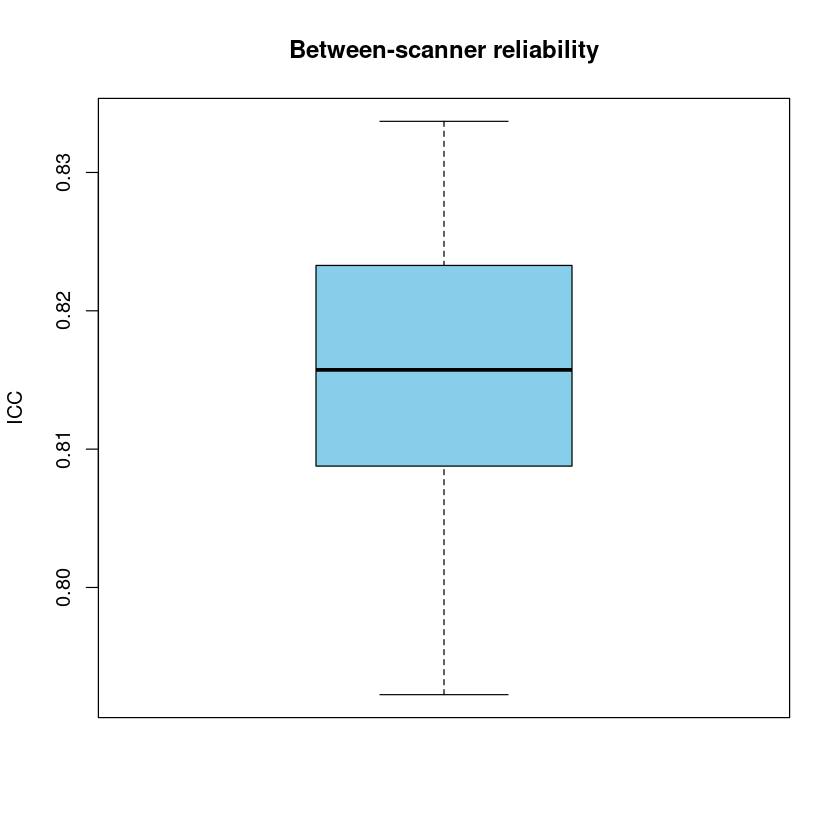

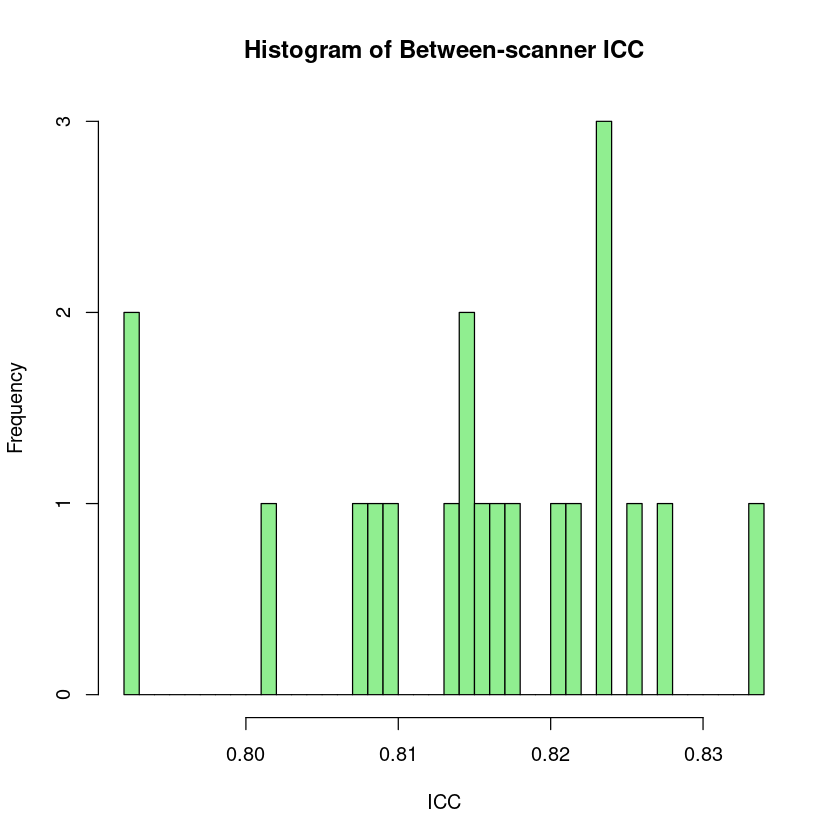

In [ ]:
mean_icc <- mean(icc_between$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_between$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_between <- rbind(
    icc_between,
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = mean_icc, summary_statistic = "mean"),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[2], summary_statistic = "median"),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25"),
    data.frame(variability_type="between-scanner", task="rest", scanner=NA, repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75")
)

boxplot(icc_between$ICC, main = "Between-scanner reliability", ylab = "ICC", col = "skyblue")
hist(icc_between$ICC, breaks = 30, main = "Histogram of Between-scanner ICC", xlab = "ICC", col = "lightgreen")

In [ ]:
icc_between

,variability_type,task,scanner,repetition,ICC,summary_statistic
,<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>
1,between-scanner,rest,NA,1-3-5,0.7922871,NA
2,between-scanner,rest,NA,2-3-5,0.7922500,NA
3,between-scanner,rest,NA,3-3-5,0.8016699,NA
4,between-scanner,rest,NA,4-3-5,0.8149459,NA
5,between-scanner,rest,NA,5-3-5,0.8231912,NA
6,between-scanner,rest,NA,6-3-5,0.8090011,NA
7,between-scanner,rest,NA,7-3-5,0.8259916,NA
8,between-scanner,rest,NA,8-3-5,0.8336963,NA
9,between-scanner,rest,NA,9-3-5,0.8212594,NA


## ICC to quantify intra-scanner variability when using standard resting-state

Let's quantify the intra-scanner reliability of FC estimates when using the standard fixation cross task for resting-state.

In [17]:
icc_within_rest <- list()
for (scanner in unique(df_fc$scanner)) {
    df_scanner <- df_fc[df_fc$scanner == scanner, ]
    df_scanner <- t(df_scanner[, edge_keys])
    icc_within_rest[[scanner]] <- icc(df_scanner, model = "twoway", type = "agreement", unit = "single")$value
    cat(sprintf("ICC of for %s scanner: %.4f\n", scanner, icc_within_rest[[scanner]]))
}
head(df_scanner)

ICC of for prisma scanner: 0.7800
ICC of for vidafit scanner: 0.7962
ICC of for vida scanner: 0.8155


,3,6,8,11,14,16,19,23,27,30,31,35
edge1,6.528042e-06,-4.514564e-06,-8.506657e-06,-3.215814e-06,-5.611867e-06,-1.163362e-06,-1.055886e-06,9.467434e-07,3.087218e-06,1.113368e-06,-4.712413e-06,-1.245544e-05
edge2,7.514955e-06,2.766009e-02,-4.268188e-06,-1.695434e-06,-9.683560e-07,3.029625e-06,-9.775773e-06,-1.016135e-06,7.646137e-07,-4.235880e-06,-6.342809e-06,8.131475e-06
edge3,6.689939e-02,1.460895e-05,9.157005e-02,9.144441e-02,3.725246e-03,1.416232e-01,9.480423e-08,4.164482e-02,1.045742e-02,-4.391880e-06,8.693893e-02,-2.167989e-05
edge4,7.235371e-06,4.672855e-04,1.805981e-02,6.709116e-02,6.825498e-02,5.305358e-02,4.791103e-02,1.185077e-02,-2.287152e-05,2.343900e-05,9.511922e-03,1.151996e-05
edge5,-7.886987e-07,-4.646385e-06,-4.847092e-06,-7.981107e-07,1.155399e-07,-1.123034e-06,7.750204e-07,-9.281694e-09,1.307680e-06,-1.880596e-06,6.730842e-08,-7.215465e-06
edge6,7.797121e-06,-2.661734e-07,-1.059137e-06,-1.370371e-06,-2.018452e-06,1.328749e-07,-2.814641e-07,-2.565683e-07,-3.477949e-07,-1.781178e-06,-2.678140e-09,5.341054e-06


Use pybids to save the ICC values for reporting in supplementary material

In [18]:
py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'figures',
    'suffix': 'bold',
    'desc': 'iccinter'
}
entities.update(entities_base)
entities.pop('task', None)
save_path = save_layout.build_path(entities, validate=False)
#")

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)

## ICC to quantify intra-scanner variability when using naturalistic movie

In [25]:
df_rsmovie <- t(df_rsmovie[, edge_keys])
head(df_rsmovie)
icc_within_rsmovie <- icc(df_rsmovie, model = "twoway", type = "agreement", unit = "single")$value
cat(sprintf("ICC for rsmovie: %.4f\n", icc_within_rsmovie))

edge1,1.102220e-06,6.415947e-06,-4.595372e-06,3.259803e-06,1.441370e-05,7.021473e-06,-1.020239e-06,5.842345e-05,-7.386642e-07,-1.819866e-06,⋯,1.427782e-07,1.067174e-06,-4.284423e-06,-1.063658e-05,-6.137563e-06,-4.678330e-06,-4.588838e-07,-5.199323e-06,-1.930210e-06,1.125792e-06
edge2,-7.794015e-07,-6.468752e-07,-2.194737e-06,-6.716801e-07,6.054336e-06,2.366883e-06,1.464118e-07,1.635985e-04,3.472887e-06,-1.046269e-07,⋯,-2.036710e-07,9.921960e-08,-3.770929e-06,3.638309e-02,-7.807891e-06,1.433800e-02,-4.062786e-07,1.576103e-02,5.235316e-02,6.780837e-06
edge3,1.139434e-05,5.280384e-06,-8.793063e-06,5.543463e-03,1.137742e-05,5.896386e-02,-1.159955e-06,4.520909e-05,-1.051122e-06,-7.542363e-06,⋯,-2.609990e-06,-2.594676e-06,-5.589937e-06,2.233237e-02,1.421963e-01,-1.567289e-05,-2.738721e-06,9.256322e-06,-1.077018e-05,5.888299e-07
edge4,-2.108473e-05,3.844471e-02,6.452152e-02,3.652434e-02,5.151805e-02,2.030996e-05,4.823714e-02,8.268471e-02,4.989634e-02,5.762318e-02,⋯,4.310278e-02,4.568402e-02,2.367034e-05,-3.039112e-05,-2.870628e-05,7.280732e-06,-5.724659e-06,-2.320633e-06,-1.551173e-06,9.287778e-06
edge5,-5.255465e-07,1.069534e-06,-1.941939e-06,1.990934e-07,6.011015e-06,-1.473689e-07,-4.917529e-07,1.050275e-04,2.452045e-07,-9.815775e-07,⋯,-1.558604e-07,3.366410e-07,-3.251314e-06,3.433093e-06,1.607545e-07,-1.188681e-06,1.352869e-07,1.584268e-08,1.891379e-07,-1.540721e-06
edge6,-6.066261e-06,4.212206e-07,-4.056693e-06,-7.268224e-07,5.638678e-06,1.130457e-06,-5.580014e-08,2.000679e-04,-1.388992e-07,-1.986019e-08,⋯,-2.985605e-07,8.313284e-08,-2.428235e-06,2.739582e-06,-3.661786e-06,6.245403e-06,-4.533894e-08,-4.280846e-07,5.141747e-07,5.194488e-06


ICC for rsmovie: 0.8726


## ICC to quantify variability across paradigms

In [30]:
icc_vals <- data.frame(edge = character(), ICC = numeric(), stringsAsFactors = FALSE)

# Randomly select 12 sessions from the rsmovie task because we need to have the same number of sessions for each task to be able to compute ICC
selected_sessions <- sample(unique(df_fc_paradigm$repetition[df_fc_paradigm$task == "rsmovie"]), 12)
df_paradigm <- df_fc_paradigm[df_fc_paradigm$repetition %in% selected_sessions | df_fc_paradigm$task == "rest", ]

for (edge in edge_keys) {
    # Keep only the edge and session columns
    df_icc <- df_paradigm[, c( "task", edge)]
    df_icc <- pivot_wider(df_icc, names_from = task, values_from = edge, values_fn = list)
    df_icc <- unnest(df_icc, cols = c(rest, rsmovie))
    # Compute ICC(2,1) for this edge
    icc_val <- icc(df_icc, model = "twoway", type = "agreement", unit = "single")$value
    icc_vals <- rbind(icc_vals, data.frame(edge = edge, ICC = icc_val))
}
df_icc
head(icc_vals)

rest,rsmovie
<dbl>,<dbl>
5.167582e-17,1.504906e-17
-3.850324e-17,6.357596e-03
1.681766e-17,2.458397e-02
-1.098919e-16,4.316731e-17
1.035807e-02,-1.522389e-17
-7.349301e-17,-2.609021e-17
-3.314509e-17,2.643575e-02
3.888169e-02,1.006888e-01
7.479356e-17,-6.822237e-17


,edge,ICC
,<chr>,<dbl>
1,edge1,0.20643815
2,edge2,-0.09054388
3,edge3,0.68388740
4,edge4,-0.20668015
5,edge5,0.30192747
6,edge6,-0.20915728


Mean ICC across edges: 0.01970949 
Median ICC across edges: 0.780564 


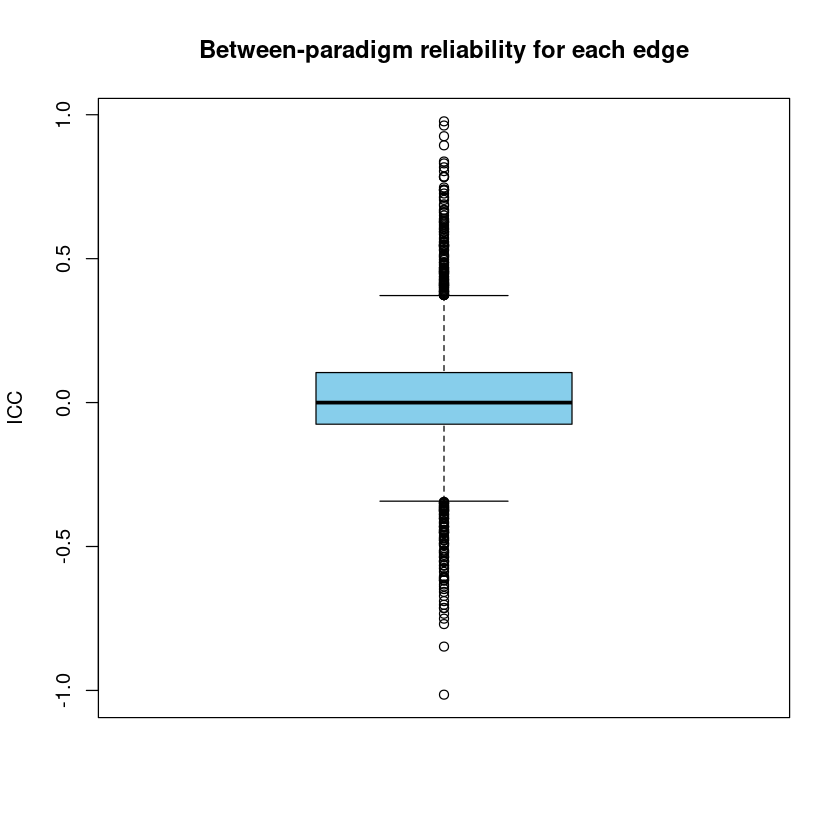

In [32]:
mean_icc <- mean(icc_vals$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
median_icc <- median(icc_results$ICC, na.rm = TRUE)
cat("Median ICC across edges:", median_icc, "\n")

boxplot(icc_vals$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")

In [44]:
icc_paradigm <- data.frame(variability_type = character(), task = character(), scanner = character(), repetition = numeric(), ICC = numeric(), summary_statistics = character(), stringsAsFactors = FALSE)

# Iterate over all possible combinations of repetition numbers for the 3 scanners
tasks <- unique(df_fc_paradigm$task)
for (rep1 in 1:12) {
  for (rep2 in 1:36) {

        # Extract that permutation of repetitions
        reps <- c(rep1, rep2)
        df_rep <- data.frame()
        for (i in 1:2) {
          df_one <- subset(df_fc_paradigm, task == tasks[i] & repetition == reps[i])
          df_rep <- rbind(df_rep, df_one)
        }
        colnames <- df_rep$task
        df_rep <- t(df_rep[, edge_keys])
        colnames(df_rep) <- colnames
        # Compute ICC(2,1) for this edge
        icc_val <- icc(df_rep, model = "twoway", type = "agreement", unit = "single")$value
        icc_paradigm <- rbind(icc_paradigm, data.frame(variability_type = "between-paradigm", task=NA, scanner="prisma", repetition = paste0(rep1, "-", rep2), ICC = icc_val, summary_statistic = NA))
    }
}
head(df_rep)
icc_paradigm

,rest,rsmovie
edge1,-1.738165e-06,1.125792e-06
edge2,-1.091652e-06,6.780837e-06
edge3,1.356319e-05,5.888299e-07
edge4,6.414071e-02,9.287778e-06
edge5,4.221924e-07,-1.540721e-06
edge6,3.592163e-07,5.194488e-06


variability_type,task,scanner,repetition,ICC,summary_statistic
<chr>,<lgl>,<chr>,<chr>,<dbl>,<lgl>
between-paradigm,NA,prisma,1-1,0.6526815,NA
between-paradigm,NA,prisma,1-2,0.7528309,NA
between-paradigm,NA,prisma,1-3,0.6810927,NA
between-paradigm,NA,prisma,1-4,0.6820359,NA
between-paradigm,NA,prisma,1-5,0.6857914,NA
between-paradigm,NA,prisma,1-6,0.7252604,NA
between-paradigm,NA,prisma,1-7,0.6759592,NA
between-paradigm,NA,prisma,1-8,0.7103866,NA
between-paradigm,NA,prisma,1-9,0.6991142,NA


Mean ICC across edges: 0.771873 
Quantiles (25%, median, 75%): 0.7203512 0.7793815 0.8267868 


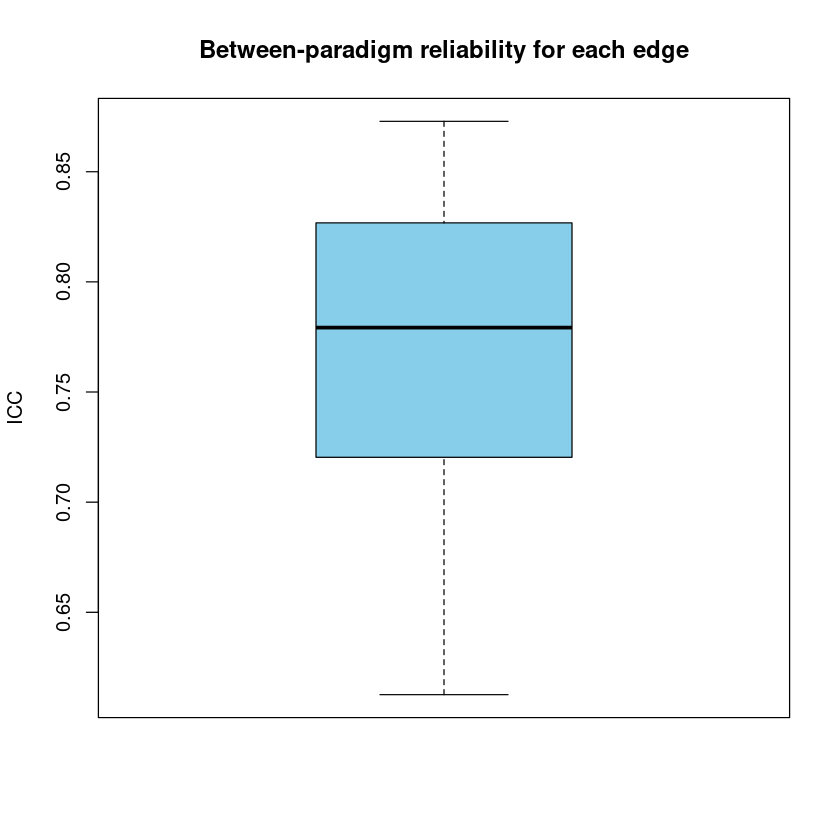

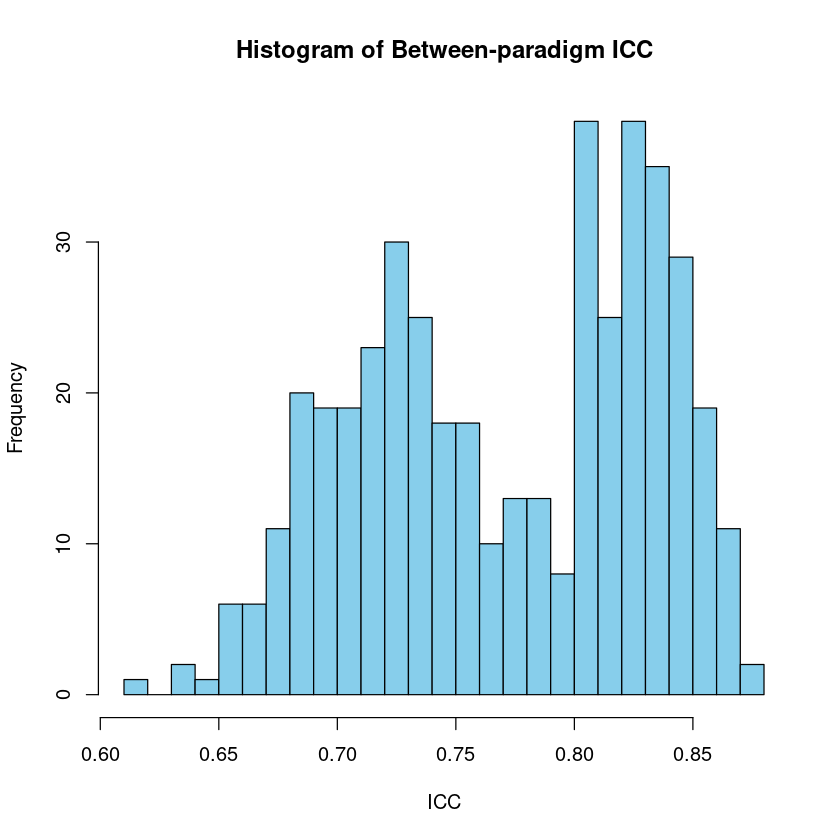

In [46]:
mean_icc <- mean(icc_paradigm$ICC, na.rm = TRUE)
cat("Mean ICC across edges:", mean_icc, "\n")
quantiles <- quantile(icc_paradigm$ICC, probs = c(0.25, 0.5, 0.75), na.rm = TRUE)
cat("Quantiles (25%, median, 75%):", quantiles, "\n")

icc_paradigm <- rbind(
    icc_paradigm,
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = mean_icc, summary_statistic = "mean"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[2], summary_statistic = "median"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[1], summary_statistic = "quantile_25"),
    data.frame(variability_type="between-paradigm", task=NA, scanner="prisma", repetition=NA, ICC = quantiles[3], summary_statistic = "quantile_75")
)

boxplot(icc_paradigm$ICC, main = "Between-paradigm reliability for each edge", ylab = "ICC", col = "skyblue")
hist(icc_paradigm$ICC, breaks = 30, main = "Histogram of Between-paradigm ICC", xlab = "ICC", col = "skyblue")

## Save the ICC estimates in a table

In [ ]:
icc_results <- rbind(icc_between, icc_paradigm)

py_run_string(" 
save_path = Path('/data/derivatives/hcph-suppl/')
save_layout = BIDSLayout(save_path, config='hcph', indexer=_indexer, validate=False)
entities = {
    'experiment': 'scannereffects',
    'extension': '.tsv',
    'datatype': 'tables',
    'suffix': 'bold',
    'desc': 'icc'
}
entities.update(entities_base)
save_path = save_layout.build_path(entities, validate=False)
#")

write.table(icc_results, file = py$save_path, sep = "\t", row.names = FALSE, col.names = TRUE, quote = FALSE)

[1] "/data/derivatives/hcph-suppl/sub-001/tables/sub-001_desc-icc_scale-64_fdthresh-05_meas-sparseinversecovariance_exp-scannereffects_bold.tsv"